[2026-06-24 20:37:45] [info     ] 🚀 开始提取高频分钟线，重构纯净 10 日动量反转因子...
[2026-06-24 20:37:49] [info     ] 📈 因子截面打分完毕，耗时: 4.91秒，正在对齐中证 1000 股票池...
[2026-06-24 20:37:50] [info     ] 🏁 官方合规性检验通过！最终交付样本行数: 241764
[2026-06-24 20:37:50] [info     ] 提取 bigalpha_2026_factorlib 进行多维正交回归评估...
[2026-06-24 20:37:50] [warning  ] bigalpha_eval._latest version='v1' (use ._latest for dev only, not for prod)
[2026-06-24 20:37:52] [info     ] bigalpha_eval.v1 开始运行 ..
[2026-06-24 20:37:54] [info     ] 合并后时间范围: 2024-01-02 至 2024-12-31
[2026-06-24 20:37:54] [info     ] ========== 数据检查 ==========
[2026-06-24 20:37:55] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14',

时段,IC
2024-01-15~2024-02-08,-0.0061
2024-09-24~2024-10-08,0.0732

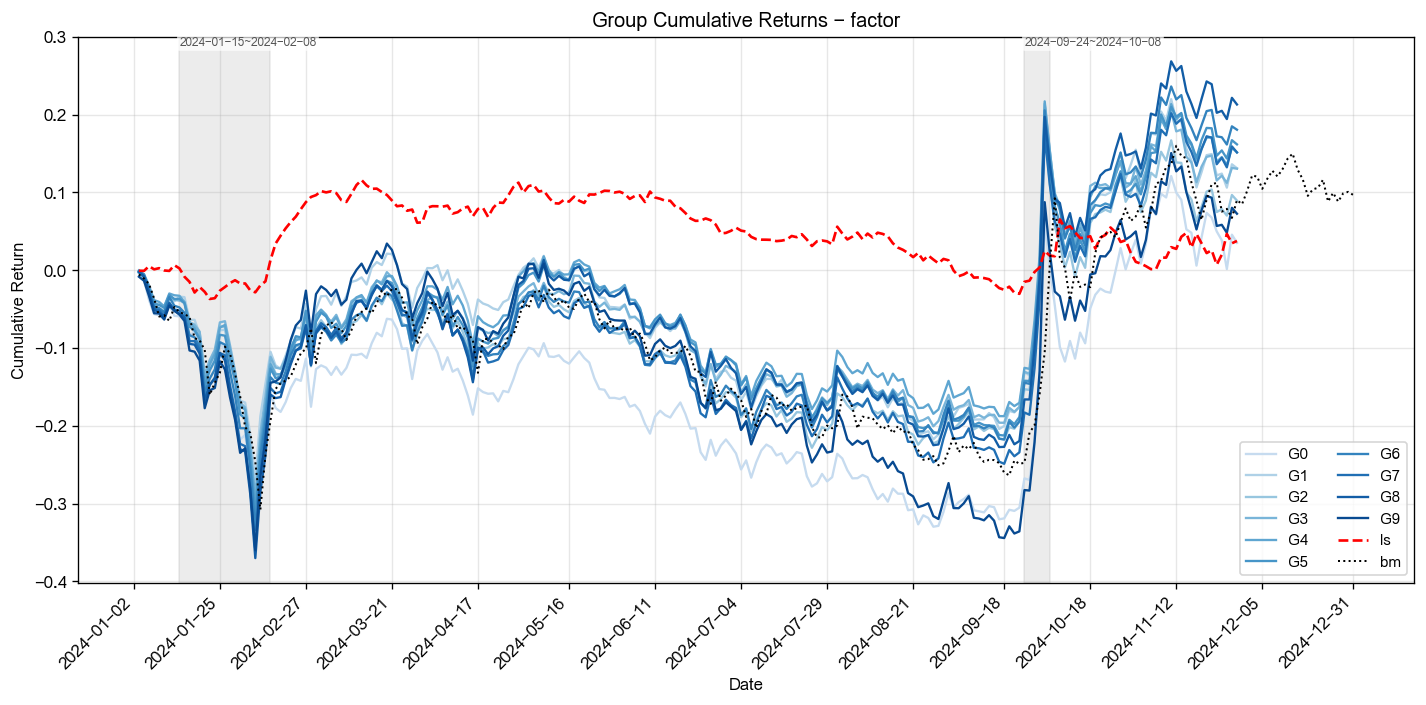
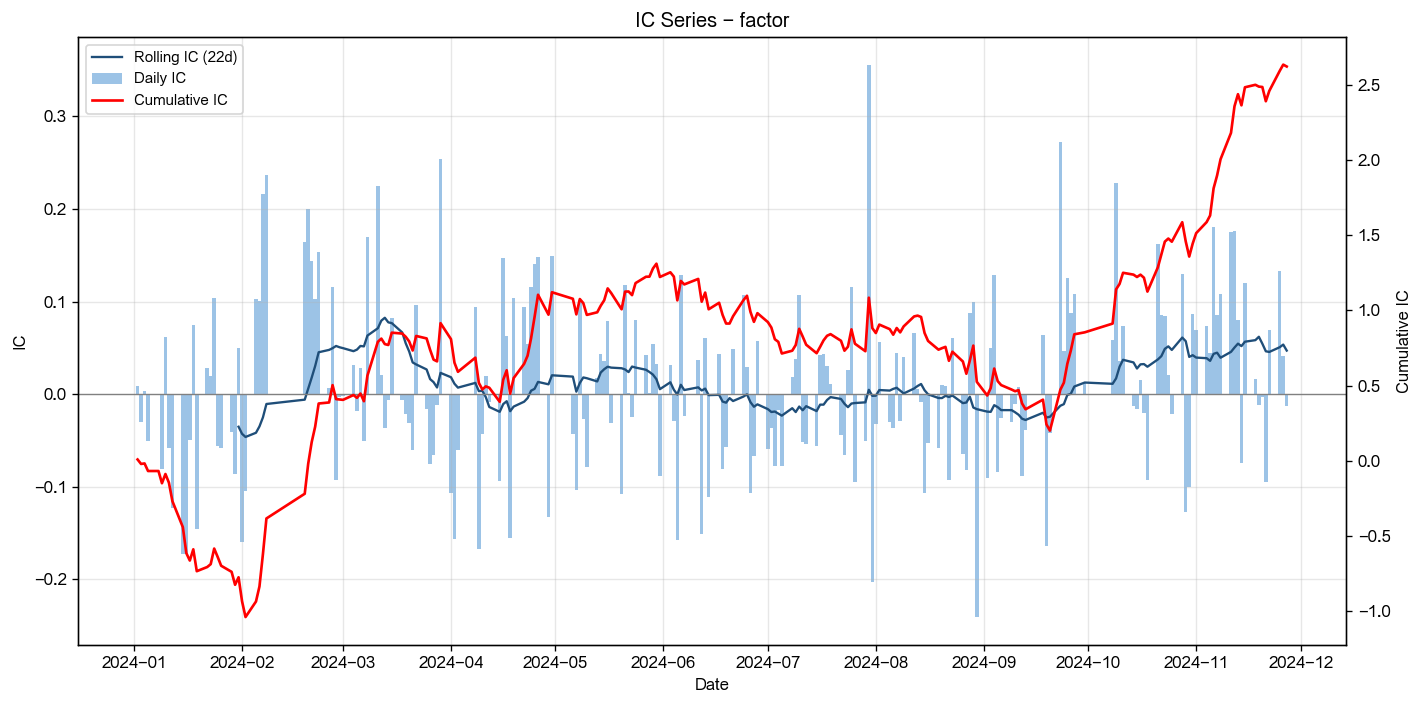
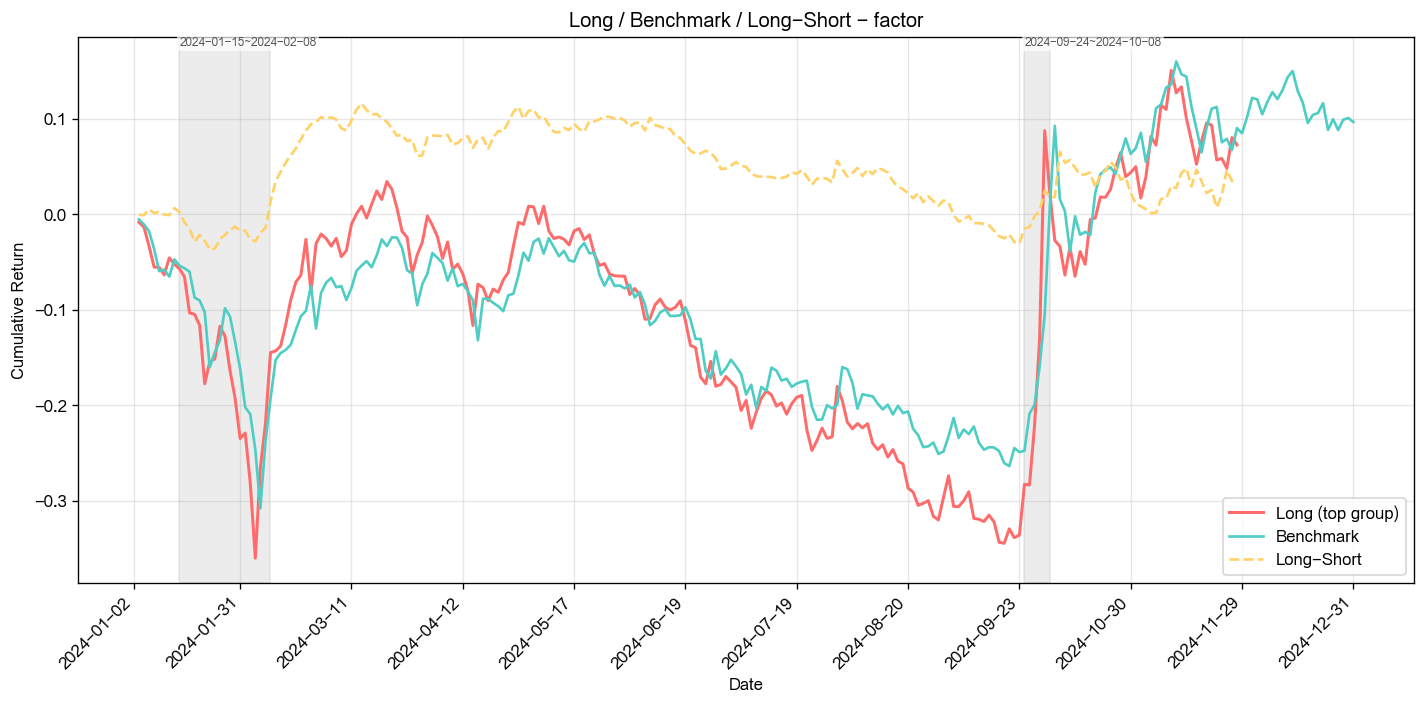
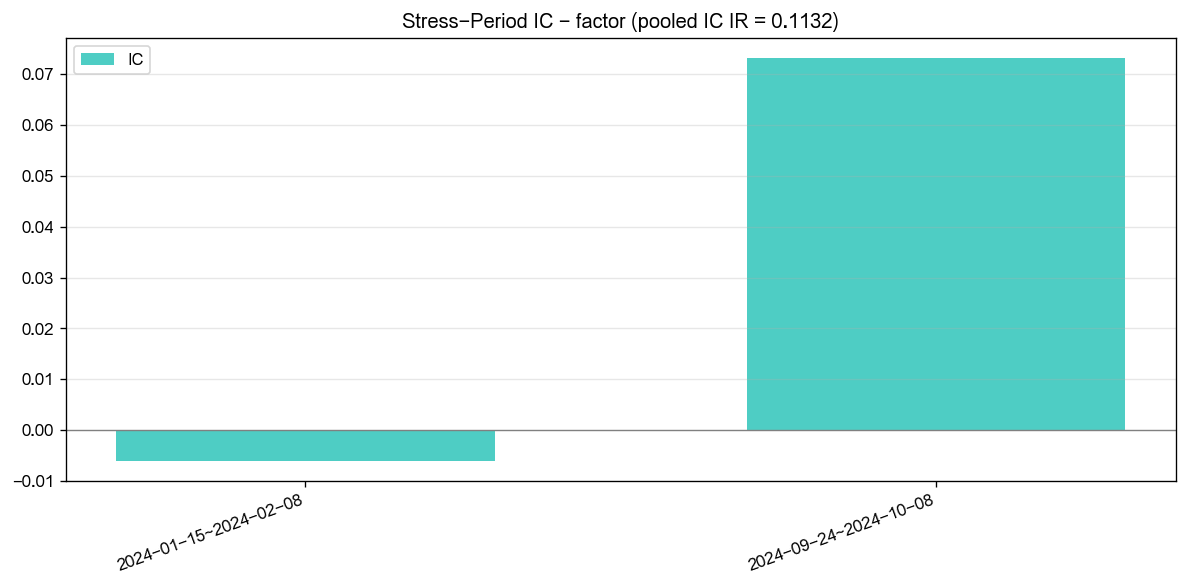
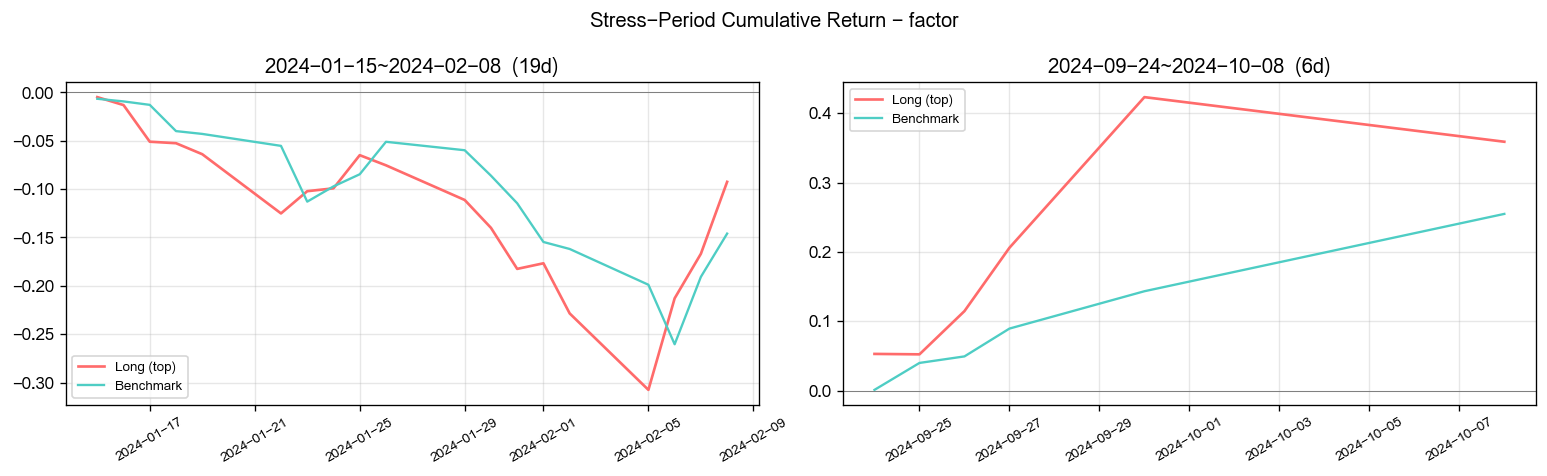

[2026-06-24 20:38:31] [info     ] ========== 因子池回归 ==========
[2026-06-24 20:38:31] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-06-24 20:38:33] [info     ] 获取收益率数据, 耗时: 2.1241 秒
[2026-06-24 20:38:33] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.6916 秒
[2026-06-24 20:38:33] [info     ] 统计 回归结果, 耗时: 0.0066 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.8977,0.0445,0.0234,1.0000
2,factor,1.8169,0.0211,0.0116,0.9000
3,amount,1.7437,0.0180,0.0103,0.9000
4,gross_profit_rate_ttm,1.5870,0.0072,0.0045,1.0000
5,netflow_amount_rate_main,1.5698,0.0099,0.0063,1.0000
6,netflow_amount_main,1.5417,0.0255,0.0165,1.0000
7,bias_20,1.5248,0.0369,0.0242,1.0000
8,net_profit_rate_ttm,1.4706,0.0040,0.0027,0.8000
9,cci_14,1.4455,0.0325,0.0225,1.0000
10,pb,1.4229,0.0096,0.0068,1.0000

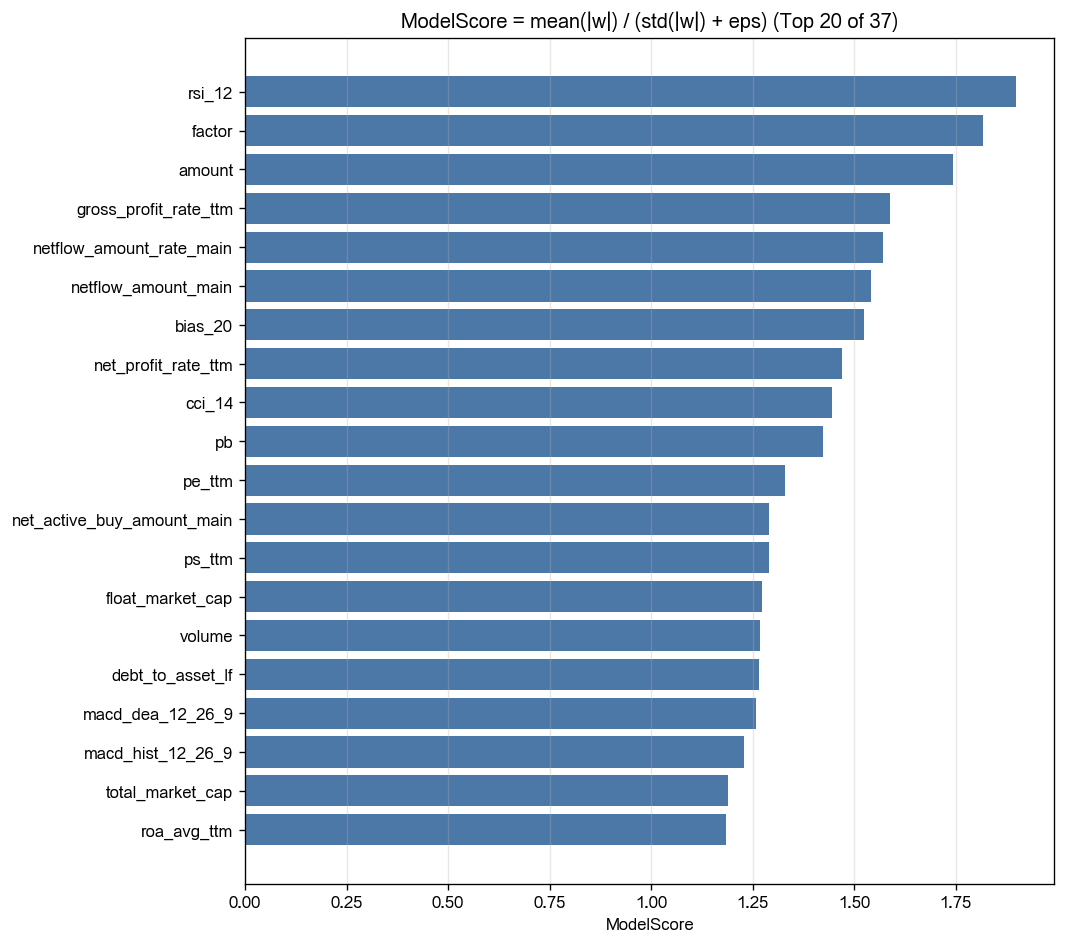
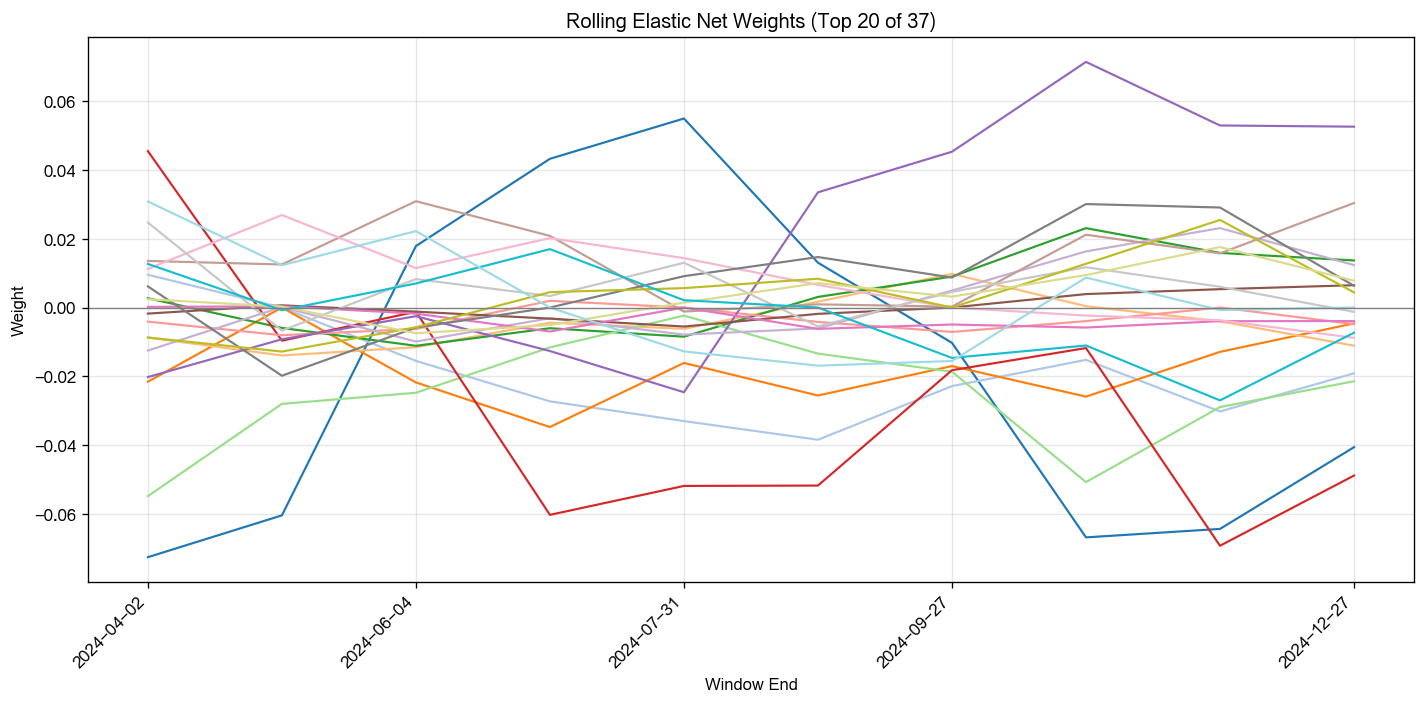
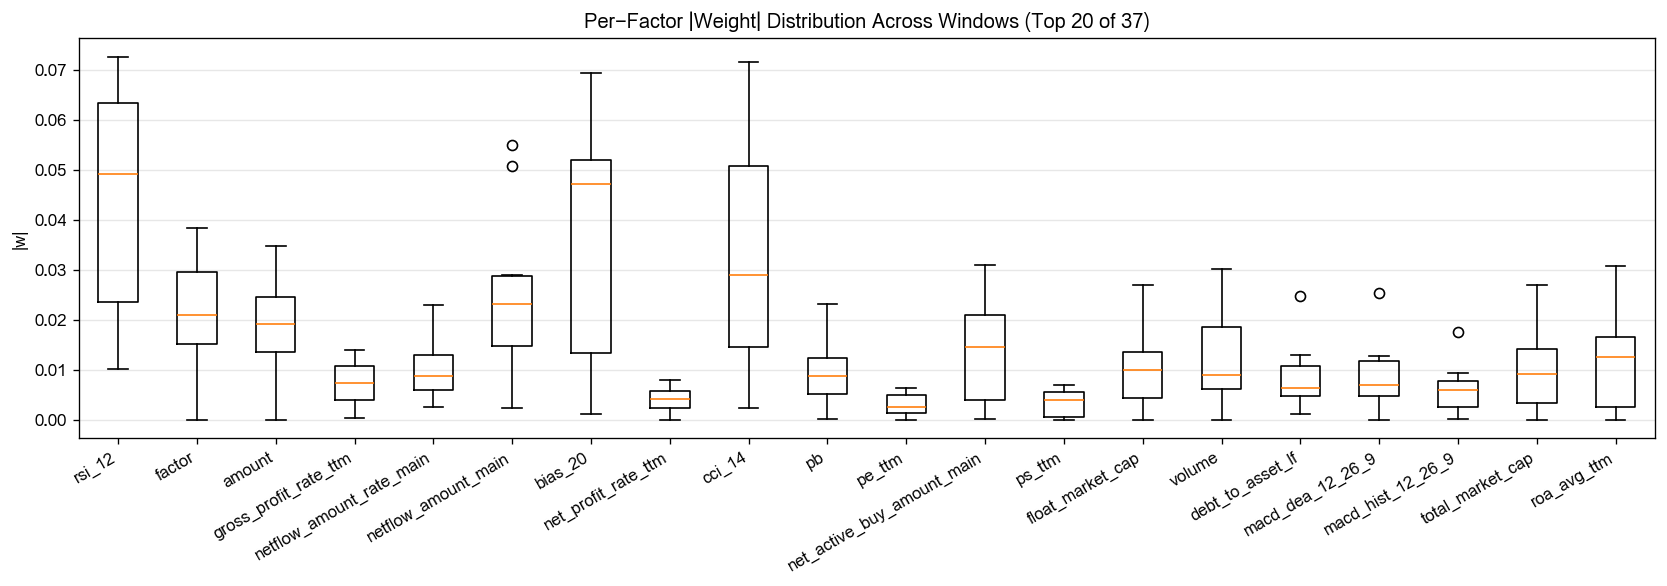
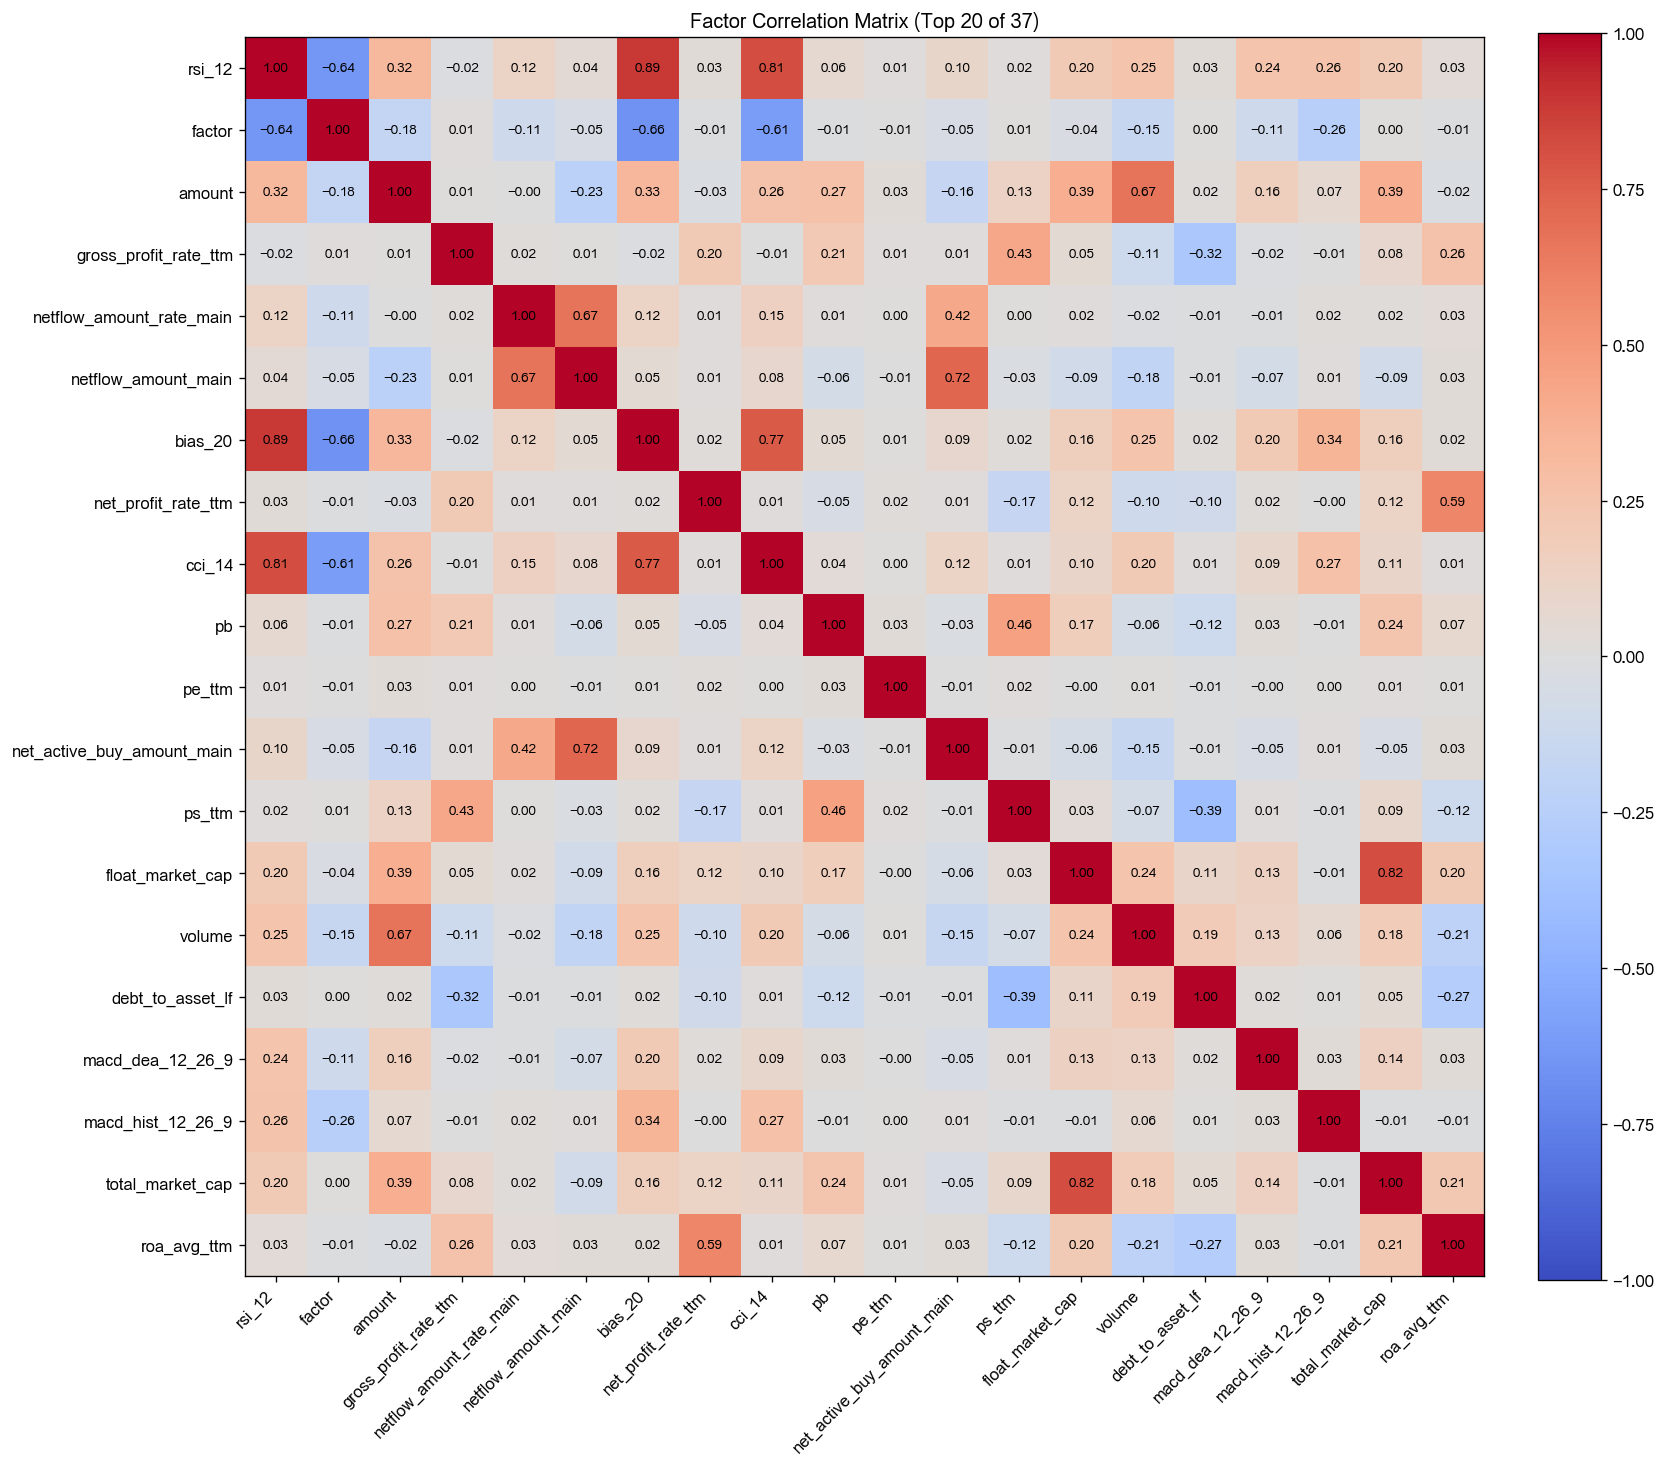

[2026-06-24 20:38:35] [warning  ] 返回的Outputs实例(size=33976742) 大于 64K, 将不会被缓存
[2026-06-24 20:38:35] [info     ] bigalpha_eval.v1 运行完成 [42.970s].


In [1]:
def main(datasources, start_date, end_date):
    """
    因子构建主函数 - 完美对齐 BigAlpha 2026 官方赛制规范
    核心因子：中证 1000 纯净 10 日动量反转因子 (-f3)
    """
    import time
    import numpy as np
    import pandas as pd
    import dai
    import structlog

    logger = structlog.get_logger()

    # 从映射里取出本阶段实际的分钟物理表名
    bar1m_table = datasources["bar1m"]

    # 考虑到要计算 10 日时序滚动，向前多取 30 天作为数据缓冲期
    LOOKBACK_DAYS = 30
    query_start_date = (pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)).strftime("%Y-%m-%d 00:00:00")
    query_end_date = pd.to_datetime(end_date).strftime("%Y-%m-%d 23:59:59")

    t0 = time.time()

    # ===== 编写符合官方数据源特征的聚合 SQL =====
    sql = f"""
    WITH cte_daily_bar AS (
        SELECT
            date::DATE::DATETIME AS date,
            instrument,
            ARG_MAX(close, date) AS close
        FROM {bar1m_table}
        WHERE ask_price1 > 0 AND bid_price1 > 0
        GROUP BY date::DATE, instrument
    ),
    cte_final_factor AS (
        SELECT
            date,
            instrument,
            -1.0 * c_pct_rank(
                (close - m_lag(close, 10)) / (m_lag(close, 10) + 1e-5)
            ) as factor
        FROM cte_daily_bar
        WHERE date BETWEEN '{query_start_date}' AND '{query_end_date}'
    )
    -- 3. 规范化最终输出字段
    SELECT
        date,
        instrument::STRING AS instrument,
        factor
    FROM cte_final_factor
    WHERE factor IS NOT NULL
    ORDER BY date, instrument
    """

    df = dai.query(sql, full_db_scan=True, compression=True).df()
    df['date'] = pd.to_datetime(df['date'])

    df = df[(df['date'] >= pd.to_datetime(start_date)) & (df['date'] <= pd.to_datetime(end_date))]
    logger.info(f"📈 因子截面打分完毕，耗时: {round(time.time()-t0, 2)}秒，正在对齐中证 1000 股票池...")

    # ===== 精准对齐官方赛制指定的股票池（中证 1000 历史成分股大底座） =====
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)

    # 实施 inner join 强对齐，保证覆盖度 100% 通过
    result = pd.merge(df, stk_pool, how='inner', on=['date', 'instrument'])
    result = result.dropna(subset=['factor']).reset_index(drop=True)
    
    logger.info(f"🏁 官方合规性检验通过！最终交付样本行数: {len(result)}")
    return result[['date', 'instrument', 'factor']]


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()
    
    # 完美复刻评测程序的自测注入环境
    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m', 
        'financial': 'bigalpha_2026_financial'
    }
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 运行主流程
    factor_data = main(datasources, start_date, end_date)

    # 读取赛事专用官方基准因子库进行多维评估
    logger.info(f"提取 bigalpha_2026_factorlib 进行多维正交回归评估...")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data, factor_pool=factor_pool, process_pools=False, show=True
    )